<a href="https://colab.research.google.com/github/Azadshokrollahi/Artificial-intelligence-for-data-science-/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##In this lab, we have 5 questions, and each question is worth 0.5 points, for a total of 2.5 points. For each question, you must not only implement the code but also explain your observations

# 📊 Data, EDA, and Preprocessing

---

## 🔹 What is Data?
- **Data** is raw information, such as numbers, text, or images, that we collect for analysis.  
- When processed and organized, data becomes meaningful and can be used to make decisions or train machine learning models.  

---

## 🔹 Structured vs Unstructured Data
- **Structured data** → Data that is neatly organized, like in tables or Excel sheets.  
  *Examples: names, phone numbers, dates.*  
- **Unstructured data** → Data that is not organized in a clear way.  
  *Examples: pictures, videos, emails, text messages.*  

---

## 🔹 Types of Data

| **Type**                   | **Subtype**   | **Meaning**                                     | **Examples** |
|-----------------------------|---------------|-------------------------------------------------|--------------|
| **Numerical (Quantitative)** | **Discrete**  | Whole numbers you can count (no decimals).      | Number of students = 30, Number of cars = 12 |
|                             | **Continuous** | Numbers you can measure (can include decimals). | Height = 175.5 cm, Weight = 68.2 kg, Temperature = 36.7°C |
| **Categorical (Qualitative)** | **Binary**   | Only 2 possible values.                         | Yes/No, Male/Female, On/Off |
|                             | **Ordinal**   | Categories with a natural order/rank.           | Education = High school < Bachelor < Master < PhD |
|                             | **Nominal**   | Categories with no order, just labels.          | Colors = Red, Blue, Green; Countries = Sweden, Iran, Italy |

---

## 🔹 1. Exploratory Data Analysis (EDA)

**What you usually do in EDA:**
- Check the shape of the dataset (rows, columns).  
- Look at missing values.  
- See the basic statistics (mean, median, min, max).  
- Make plots (histograms, boxplots, scatterplots) to understand distributions and relationships.  
- Detect outliers or unusual data points.  

📊 **Example**: If you have a dataset of students’ scores, EDA helps you see:  
- Average score  
- Who scored the highest and lowest  
- Whether boys and girls performed differently  
- If there are missing exam results  

---

## 🔹 2. Preprocessing

 Preprocessing means **cleaning and preparing raw data** so it can be used for analysis or training models.  

**Common Steps in Preprocessing:**
- **Cleaning data**   
  - Handle missing values (fill them, drop them).  
  - Remove duplicates.  
  - Correct wrong or inconsistent values.  

- **Transforming data**
  - Convert text into numbers (e.g., Male = 0, Female = 1).  
  - Normalize/scale numerical values (e.g., make all features between 0 and 1).  

- **Reducing data**  
  - Drop irrelevant columns.  
  - Use feature selection or dimensionality reduction (like PCA).  

- **Splitting data**   
  - Divide into training set and test set.  

 **Example**: If you have house price data:  
- Remove rows where the price is missing.  
- Convert “Yes/No” for garage into 1/0.  
- Scale square meters so they’re comparable to number of rooms.  
- Split into training (80%) and test (20%).  

 In short: Preprocessing = making raw data **clean, consistent, and ready to use**.  



## **🔸 Imports**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import  missingno as msno

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Imported libraries")

Imported libraries


## **🔸 Hello Data**

### Load dataset

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/Azadshokrollahi/Artificial-intelligence-for-data-science-/main/insurance.csv"
df = pd.read_csv(url)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,NaN,male,33.770,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,4449.46200
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,no,northwest,3866.85520


In [5]:
df.shape

(1338, 7)

In [6]:
df.dtypes

age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges     float64
dtype: object

### Access to rows and columns

In [7]:
df.iloc[0:3, 2:4]

,bmi,children
0,27.90,0.0
1,33.77,1.0
2,33.00,3.0


In [8]:
df.iloc[[0, 1337]]

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.90,0.0,yes,southwest,16884.9240
1337,61.0,female,29.07,0.0,yes,northwest,29141.3603


In [9]:
df.iloc[:, [0]]

,age
0,19.0
1,NaN
2,28.0
3,33.0
4,32.0
...,...
1333,50.0
1334,18.0
1335,NaN
1336,21.0


In [9]:
df[['children', 'sex']]
df.children

0       0.0
1       1.0
2       3.0
3       0.0
4       0.0
       ... 
1333    3.0
1334    0.0
1335    0.0
1336    0.0
1337    0.0
Name: children, Length: 1338, dtype: float64

### Make a codable dataset

In [10]:
df.columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
df

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,NaN,male,33.770,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,4449.46200
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50.0,male,30.970,3.0,no,northwest,10600.54830
1334,18.0,female,31.920,0.0,no,northeast,2205.98080
1335,NaN,female,36.850,0.0,no,southeast,1629.83350
1336,21.0,female,25.800,0.0,no,southwest,2007.94500


# **Question 1: Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is the process of exploring a dataset to understand its structure, main characteristics, and patterns before applying any machine learning model.  
The goal is to **summarize the data, find relationships, and detect trends or anomalies**.  

In EDA, we often use:  
- **Statistical summaries** → `df.describe()`  
- **Correlation analysis** → `df.corr()`
- **Visualizations** such as:  
  - Histograms → show distributions of individual features  
  - Subplots → compare multiple features at once  
  - Pair plots → show relationships between features  

---

### **Student Task**

1. Perform EDA on the dataset using:  
   - `df.describe()`  
   - `df.corr()`
   - Different diagrams such as **histogram, subplot, and pair plot**  

2. In a **text cell**, write down your **observations**:  
   - What do you notice about the distribution of values?  
   - Which features are correlated (positively or negatively)?  
   - Did you find any unusual patterns or outliers?  


In [11]:
#implement the code for Question 1 here
df.describe()

,age,bmi,children,charges
count,1318.000000,1284.000000,1205.000000,1338.000000
mean,39.528832,30.629611,1.075519,13270.422265
std,13.909197,6.061066,1.204273,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.220000,0.000000,4740.287150
50%,40.000000,30.300000,1.000000,9382.033000
75%,51.000000,34.520000,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.127679,0.053548,0.298536
bmi,0.127679,1.000000,0.021078,0.172537
children,0.053548,0.021078,1.000000,0.071236
charges,0.298536,0.172537,0.071236,1.000000


## Answer

2. In a **text cell**, write down your **observations**:  
   - What do you notice about the distribution of values?  
      - `age` ranges from 18 to 64 and is fairly spread  across the range
      - `bmi`'s mean is around 30.6, with 1st quantile and 3rd quantile are 26.2 and 34.5 respectively.
      - `children` has a lower range compared to other numeric features, with median of 1 and a maximum of 5
      - `charges`seems to be right-skewed, since the mean of 13270 is much higher than the median of 9382. It appears that there are few observations have very high insurance charges that affects the mean to be higher noticeably than the medium.

   - Which features are correlated (positively or negatively)?  
      - All correlations between the numeric features appear to have postive correlation with different extents.
      - `charges`seems to have a positive relationship with `age`, meaning that the older individuals tend to have higher insurance charges (which makes sense)
      - `charges` and `bmi`,  have a weaker positive relationship 
      - `age` and `bmi` appear to have some positive relationship

   - Did you find any unusual patterns or outliers?  
      - Due to the large deviation between median and mean together with the noticeable high maximum charge compared with mean and the other quantiles, `charges` contains some very high values, suggesting high-value outliers.
      - `bmi` also contains some unusually high values, with maximum of 53.13 and medium of 30.3

**Observations**




### Examining categorical and numerical features

In [ ]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1318 non-null   float64
 1   sex       1338 non-null   object 
 2   bmi       1284 non-null   float64
 3   children  1205 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(4), object(3)
memory usage: 73.3+ KB


age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges     float64
dtype: object

In [ ]:
df[['sex', 'smoker', 'region']] = df[['sex', 'smoker', 'region']].astype('category')
df.dtypes

age          float64
sex         category
bmi          float64
children     float64
smoker      category
region      category
charges      float64
dtype: object

# 🔸 Missing Values

In real-world datasets, we often encounter **missing values**.  
This means some entries in the dataset are not recorded or are left blank.  

### 🔹 Why do missing values occur?
- Human error (e.g., survey questions left unanswered).  
- Sensor/device errors (e.g., skipped sensor readings).  
- Privacy reasons (e.g., people not reporting their income).  
- Data corruption or transfer issues.  

Handling missing values correctly is important because they can affect the accuracy of analysis and machine learning models.  

---

## 🔹 Types of Missing Values

| **Type**                                | **Meaning**                                                                      | **Example**                                                                                           | **Difficulty**                                     |
| --------------------------------------- | -------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- | -------------------------------------------------- |
| **MCAR** (Missing Completely At Random) | Missing values occur randomly, unrelated to any data.                            | A sensor randomly skips a reading.                                                                    |  Easy to handle (no bias).                        |
| **MAR** (Missing At Random)             | Missingness depends on **other observed data**, not on the missing value itself. | Older people are less likely to report income (missingness depends on **age**, which is known).       |  Medium (can use imputation/statistical models). |
| **MNAR** (Missing Not At Random)        | Missingness depends on the **missing value itself**.                             | People with very high income do not report it (missingness depends on **income**, the missing value). |  Hard (needs assumptions or extra data).          |

---




In [17]:
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1318 non-null   float64
 1   sex       1338 non-null   object 
 2   bmi       1284 non-null   float64
 3   children  1205 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(4), object(3)
memory usage: 73.3+ KB


age          20
sex           0
bmi          54
children    133
smoker        0
region        0
charges       0
dtype: int64

In [18]:
df.isnull().sum()

age          20
sex           0
bmi          54
children    133
smoker        0
region        0
charges       0
dtype: int64

<Axes: >

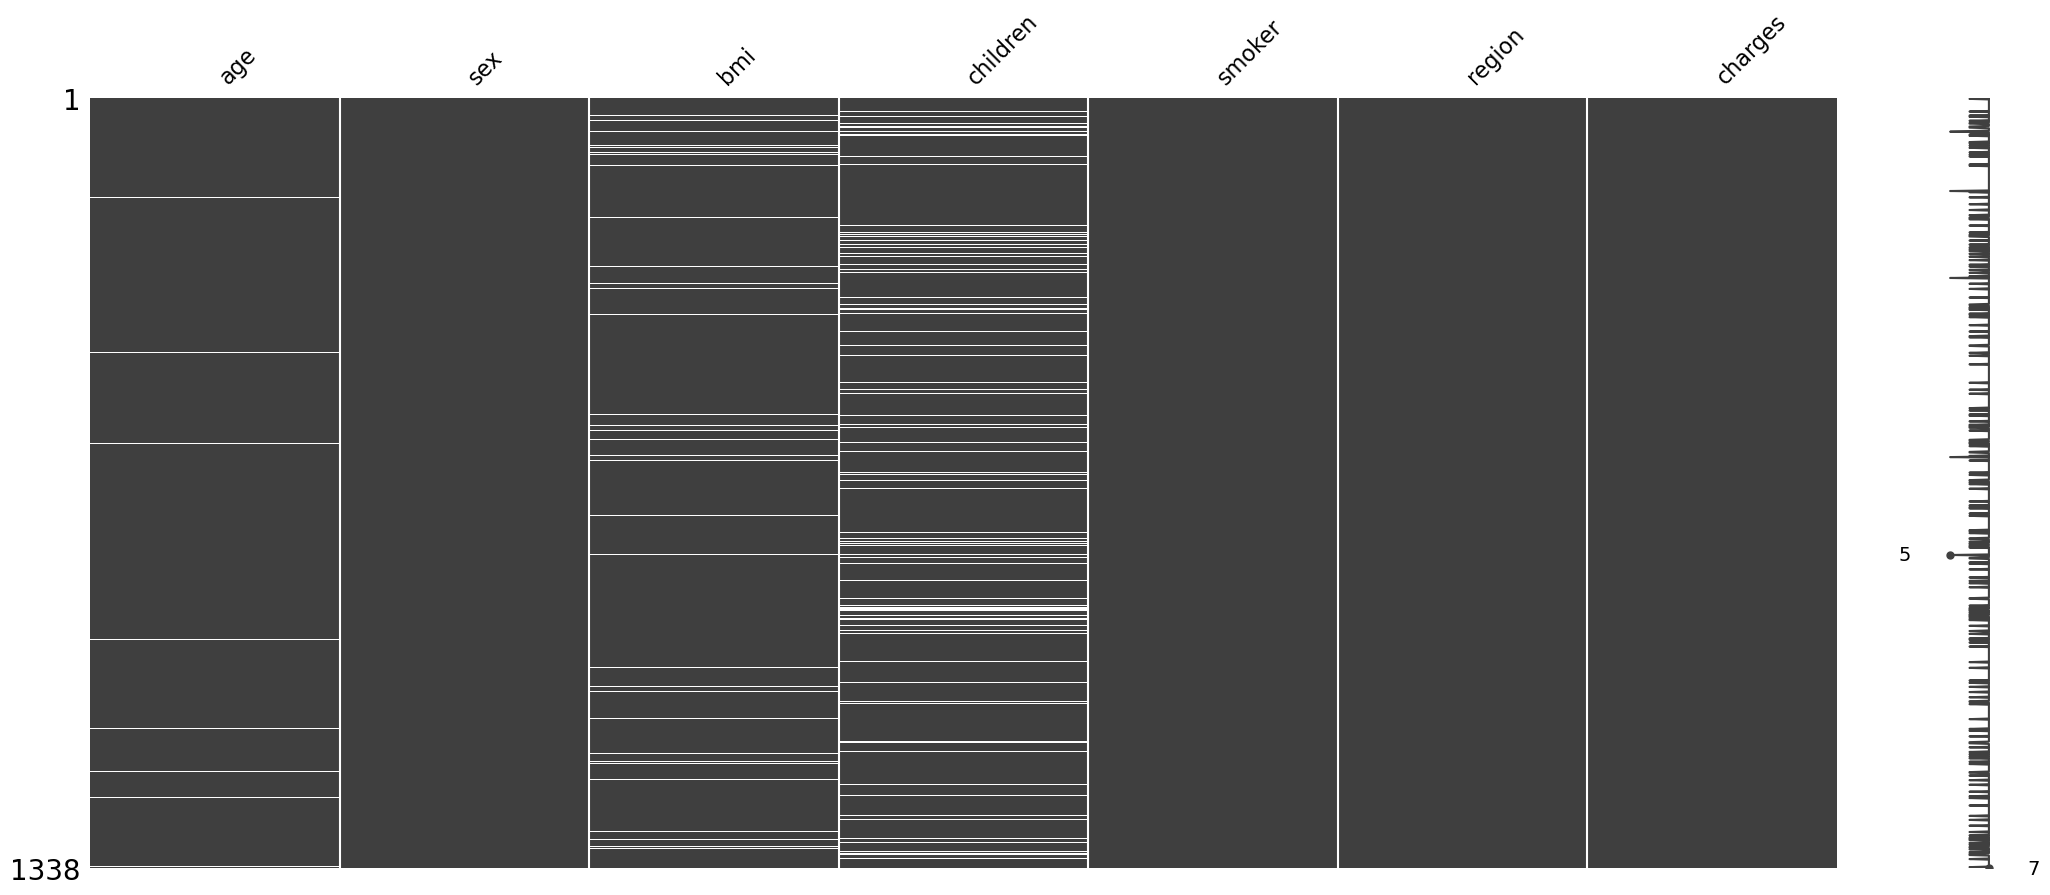

In [19]:
msno.matrix(df)

### Diagnose missing values

#  Question 2: Diagnosing Missing Values with Histograms

In this exercise, you will investigate **missing values** in a dataset and decide whether they are **MCAR, MAR, or MNAR**.  

We will use **histograms** to compare distributions of features with and without missing values.  

---

### **Your Coding Task**

Write a Python function called `diagnose_mv(df, mv_column)` that:

1. **Inputs**:
   - `df`: a pandas DataFrame  
   - `mv_column`: the column that has missing values  

2. **For each feature (column) in the dataset**:
   - Plot a **histogram** of the feature using **all rows** (this includes rows where `mv_column` is missing).  
   - Plot another **histogram** of the same feature, but only using rows where `mv_column` is **not missing**.  
   - Plot a **bar chart** showing the **absolute difference** between the two histograms (bin by bin).  

3. **Arrange the plots**:
   - Left → histogram with all rows  
   - Middle → histogram without rows where `mv_column` is missing  
   - Right → bar chart showing the difference  

---

### **Interpretation Task**

After you run your function and generate the histograms:

- Compare the shapes of the histograms.  
- Decide whether the missingness in your dataset looks like **MCAR, MAR, or MNAR**.  
- Write your conclusion in a **text cell** (5–10 sentences) explaining what you observed.  


In [27]:
df.select_dtypes(include=np.number).columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [97]:
df["smoker"].value_counts().reindex(["yes", "no"]).values

array([ 274, 1064])

##### ** Function

In [130]:
def diagnose_mv(df : pd.DataFrame, mv_column: str) -> None:
    """
    Compare feature distribution before and after removing rows where mv_column is missing. This function will plot three subplots:
    1. Histogram of the feature using all rows (including rows where mv_column is missing)
    2. Histogram of the feature using only rows where mv_column is not missing
    3. Bar chart showing the absolute difference between the two histograms (bin by bin)
    Args:
        df (pd.DataFrame): input dataset
        mv_column (str): the column name that contains missing values
    Returns:
        None
    """
    df_nonNull = df[df[mv_column].notna()] #Dataset where mv_column is not missing
    numeric_cols = df.select_dtypes(include=np.number).columns 
    n_features = len(df.columns) #number of features in the dataset
    fig, ax = plt.subplots(n_features, 3, figsize = (12, n_features * 1.5)) #3 subplots for each feature per row
    bar_width = 0.8 #width of the bars in the bar chart
    for i,feature in enumerate(df.columns):
        if feature in numeric_cols:
            values_all = df[feature].dropna() #ALL VALUES including missing mv_column. plotting purpose only, so we can dropna for the plotted featuree
            values_nonNull = df_nonNull[feature].dropna() #Exclude rows where mv_column is missing. plotting purpose only
        
            bin_edges = np.histogram_bin_edges(values_all, bins = 10)
            
            counts_all = np.histogram(values_all, bins = bin_edges)[0]
            counts_nonNull = np.histogram(values_nonNull, bins = bin_edges)[0]
            
            diff_counts = np.abs(counts_all - counts_nonNull)
            
            ax[i, 0].hist(values_all, bins = bin_edges)
            ax[i, 1].hist(values_nonNull, bins = bin_edges)
            ax[i, 2].bar(x = bin_edges[:-1], height = diff_counts, width = np.diff(bin_edges))
        
        else:
            categories = df[feature].dropna().unique()
            count_all = df[feature].value_counts().reindex(categories, fill_value=0)
            count_nonNull = df_nonNull[feature].value_counts().reindex(categories, fill_value=0)
            diff_counts = np.abs(count_all - count_nonNull)
            
            x = np.arange(len(categories)) #position of the bars
            
            ax[i, 0].bar(x, count_all.values, width = bar_width)
            ax[i, 0].set_xticks(x)
            ax[i, 0].set_xticklabels(categories)
            
            ax[i, 1].bar(x, count_nonNull.values, width = bar_width)
            ax[i, 1].set_xticks(x)
            ax[i, 1].set_xticklabels(categories)

            ax[i, 2].bar(x, diff_counts, width = bar_width)
            ax[i, 2].set_xticks(x)
            ax[i, 2].set_xticklabels(categories)

        ax[i, 0].set_title(f'{feature} with missing {mv_column}')
        ax[i, 1].set_title(f'{feature} without missing {mv_column}')
        ax[i, 2].set_title(f'Difference')
        
        plt.tight_layout()
    return
    
    

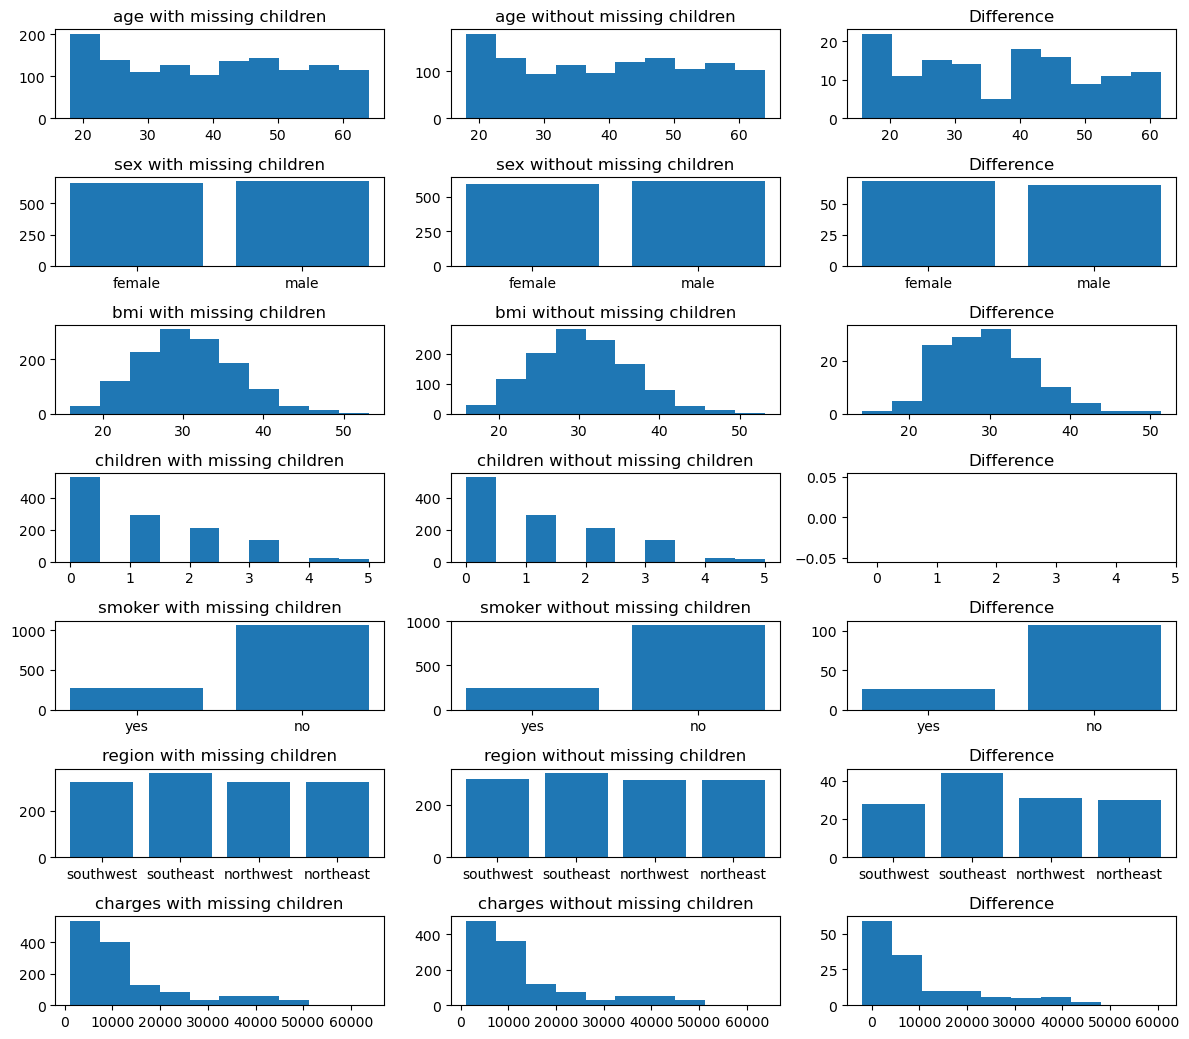

In [131]:
diagnose_mv(df, 'children')

#### * BMI

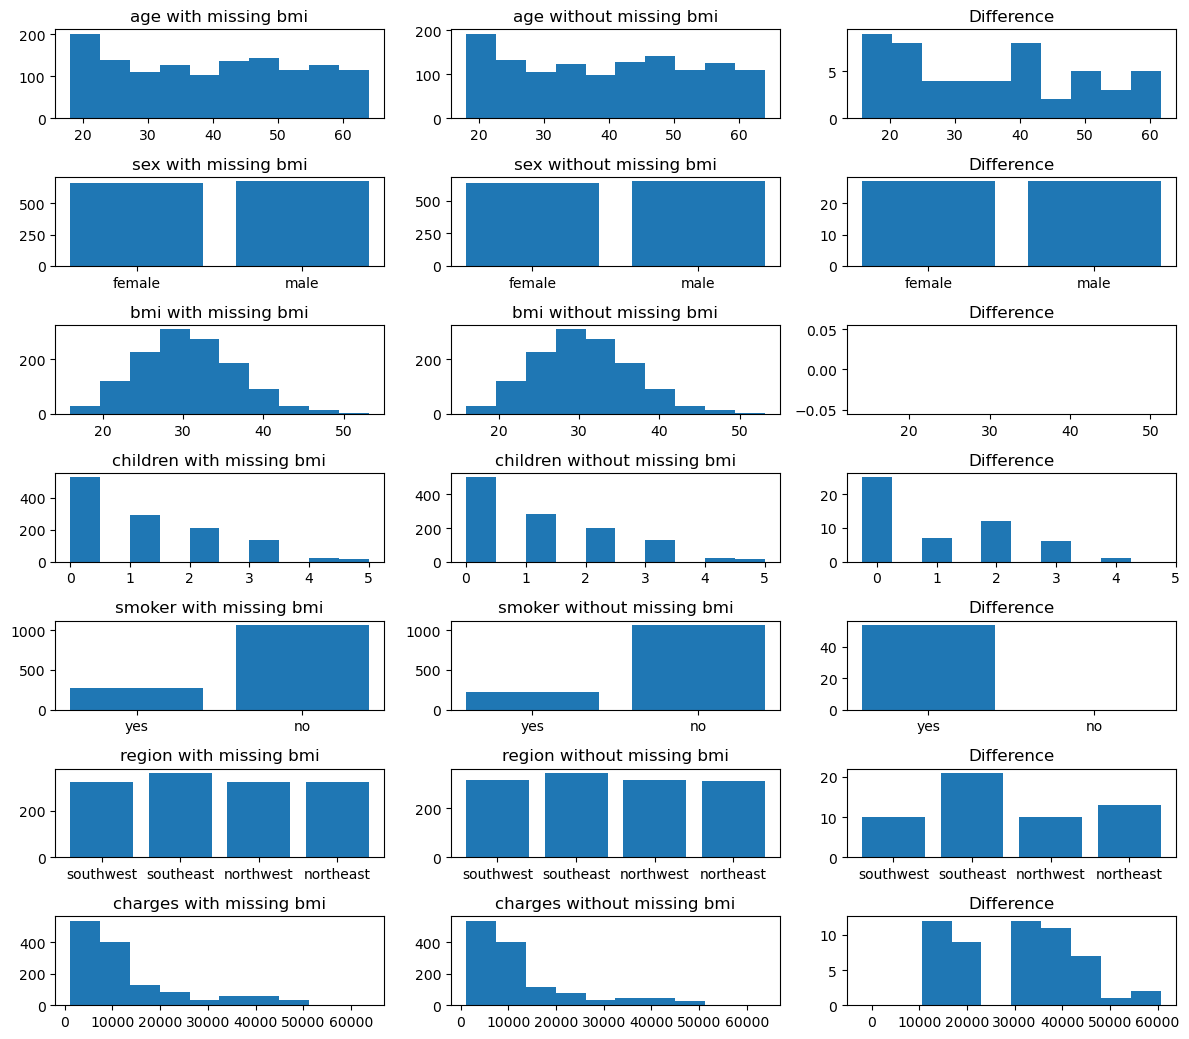

In [132]:
diagnose_mv(df, 'bmi')

#### * Age

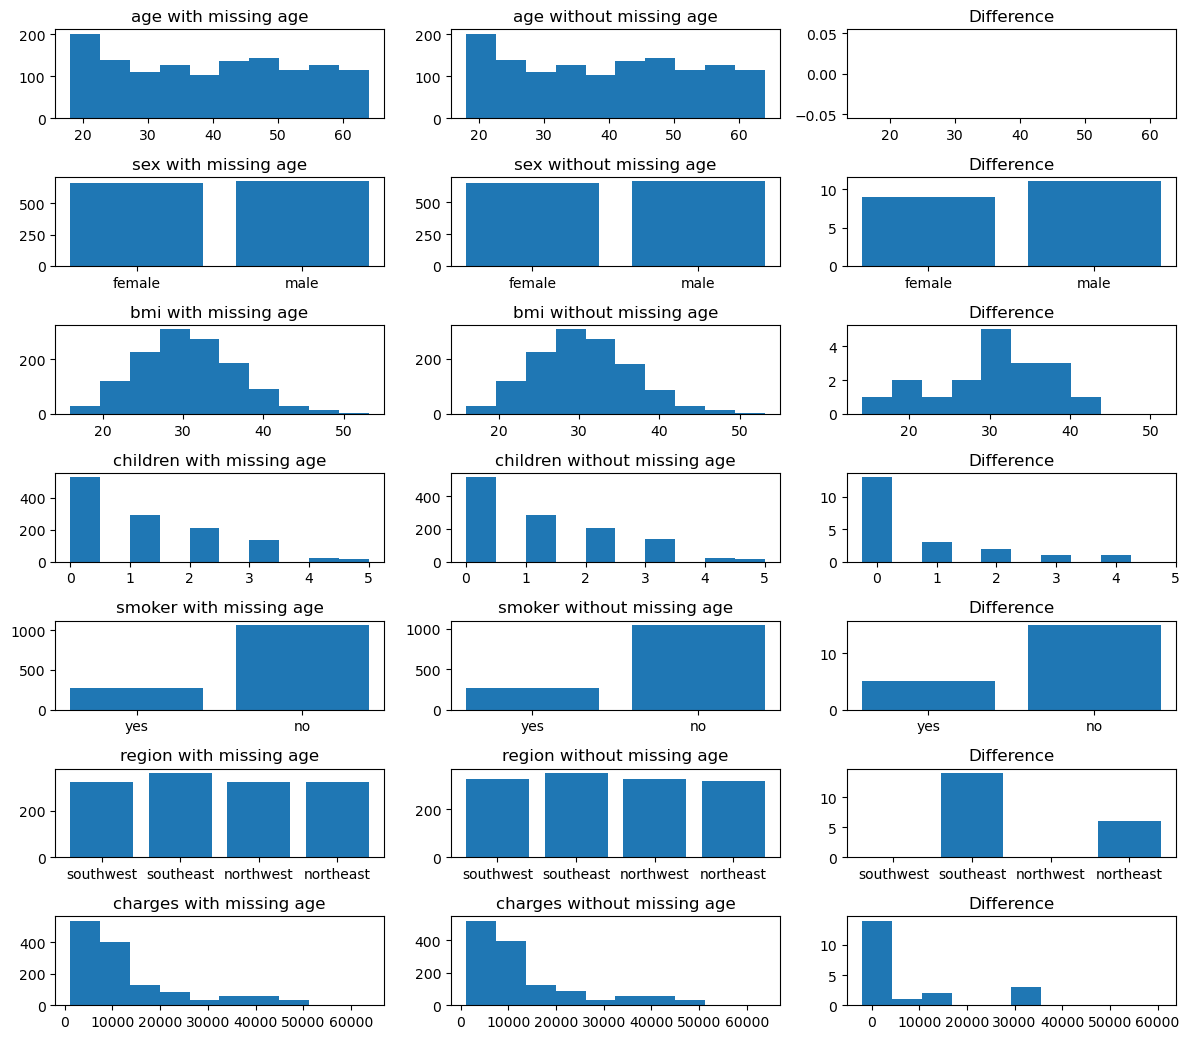

In [133]:
diagnose_mv(df, 'age')

**Observation 2**

### Answer for Question 2:

- Compare the shapes of the histograms.  
- Decide whether the missingness in your dataset looks like **MCAR, MAR, or MNAR**.  
- Write your conclusion in a **text cell** (5–10 sentences) explaining what you observed.  

The missing values in this dataset look more like MAR, Missing at random than MCAR or MNAR. The clearest evidence is for `bmi`. The missing BMI values are concentrated among people with `smoker = yes`, while there is almost no difference for `smoker = no`. Missing `age` also does not look completely random, since the differences across `region` are uneven, especially for `southeast` and `northeast`.  The distribution of `age`, `bmi`, `charges` also mostly keep the same shape, even though some bins lose more observations than others. Because missingness in some columns is related to other features that we can observe, I would not classify the dataset at MCAR. I also do not see enough evidence for MNAR, since these plots do not show whether a value is missing because of the missing value itself.

The missing values do not follow the same pattern. For `children`, the differences are more spread out and the overall shapes before and after removing missing rows stay quite similar. Because the is no clear relationship between missing `children` values and the observed variables, I would treat `children` as MCAR. For `bmi`, the pattern is different. The missing BMI values are concentrated among people with `smoker = yes`, while there is almost no difference for `smoker = no`. THis suggests the missningness in `bmi` depends on another variable, so I would classify `bmi` as MAR. Missing `age` also does not look completely random, since the differences across `region` are uneven, especially for `southeast` and `northeast`. However, these plots are not enough to conclude that `age` is MNAR, because MNAR means that the probability of `age` being missing depends on the missing age itself, which we cannot observe. 

# 🔸 Handling Missing Values

Once we identify the type of missing data, we need to choose the right strategy to handle it.  
Different approaches are suitable for **MCAR, MAR, and MNAR**.  

---

## Handling Strategies

| **Type** | **Best Handling Methods** | **Notes** |
|----------|---------------------------|-----------|
| **MCAR** (Missing Completely At Random) | - Drop rows with missing values (safe, no bias) <br> - Drop entire column (if too many missing values) <br> - Simple imputation (mean, median, mode) | Since missingness is random, any method works without bias. |
| **MAR** (Missing At Random) | - Use **imputation based on other features** (regression imputation, KNN imputer, multiple imputation) <br> - Group-wise imputation (e.g., fill income by median per age group) | Missingness is linked to other variables, so we must use them to estimate. |
| **MNAR** (Missing Not At Random) | - Add a “missing” indicator/flag column <br> - Use **domain knowledge** or expert rules to fill values <br> - Sensitivity analysis <br> - Sometimes drop rows (but may bias results) | Hardest to handle because the missingness depends on the missing value itself. Often needs external info or careful modeling. |

---

 **Summary:**  
- **MCAR** → easiest, can drop or use simple fill (mean/median/mode).  
- **MAR** → medium, use relationships with other features to impute.  
- **MNAR** → hardest, may need domain knowledge, missing flags, or more data.  


## Question 3: Handling Different Types of Missing Values

Now that you know how to identify MCAR, MAR, and MNAR, let’s practice handling them in a dataset.  

### **Your Task**

For each of the following cases, apply the correct method to handle missing values:  

1. **MCAR**  
   - Missing values are random.  
   - Replace missing values with the **mode** (most frequent value).  

2. **MAR**  
   - Missing values depend on another variable.  
   - Use **conditional imputation**, such as replacing missing values with the **median** (or mean) within subgroups.  

3. **MNAR**  
   - Missing values depend on the value itself.  
   - Handle them by **dropping rows** with missing values, or by creating a **“missing” indicator column**.  

---

After handling the missing values:  
- Use `msno.matrix(df)` (or another visualization) to verify that there are no missing values left.  
- In a **text cell**, explain in 2–3 sentences why you chose:  
  - Mode for MCAR  
  - Median (conditional) for MAR  
  - Row deletion (or indicator) for MNAR  


In [169]:
df_clean = df.copy()
df.isna().sum()

age          20
sex           0
bmi          54
children    133
smoker        0
region        0
charges       0
dtype: int64

#### * Children

Replace missing values with mode (MAR)

In [170]:
children_mode = df_clean["children"].mode()[0]
df_clean["children"] = df_clean["children"].fillna(children_mode)
df_clean.isna().sum()

age         20
sex          0
bmi         54
children     0
smoker       0
region       0
charges      0
dtype: int64

#### * BMI

In [171]:
df_clean.groupby('smoker')['bmi'].median()


smoker
no     30.3525
yes    30.1100
Name: bmi, dtype: float64

In [172]:
df_clean['bmi'] = df_clean['bmi'].fillna(df_clean.groupby('smoker')['bmi'].transform('median'))
df_clean.isna().sum()

age         20
sex          0
bmi          0
children     0
smoker       0
region       0
charges      0
dtype: int64

#### * Age

In [173]:
df_clean['age_missing_indicator'] = df_clean['age'].isna().astype(int)

df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean.isna().sum()

age                      0
sex                      0
bmi                      0
children                 0
smoker                   0
region                   0
charges                  0
age_missing_indicator    0
dtype: int64

<Axes: >

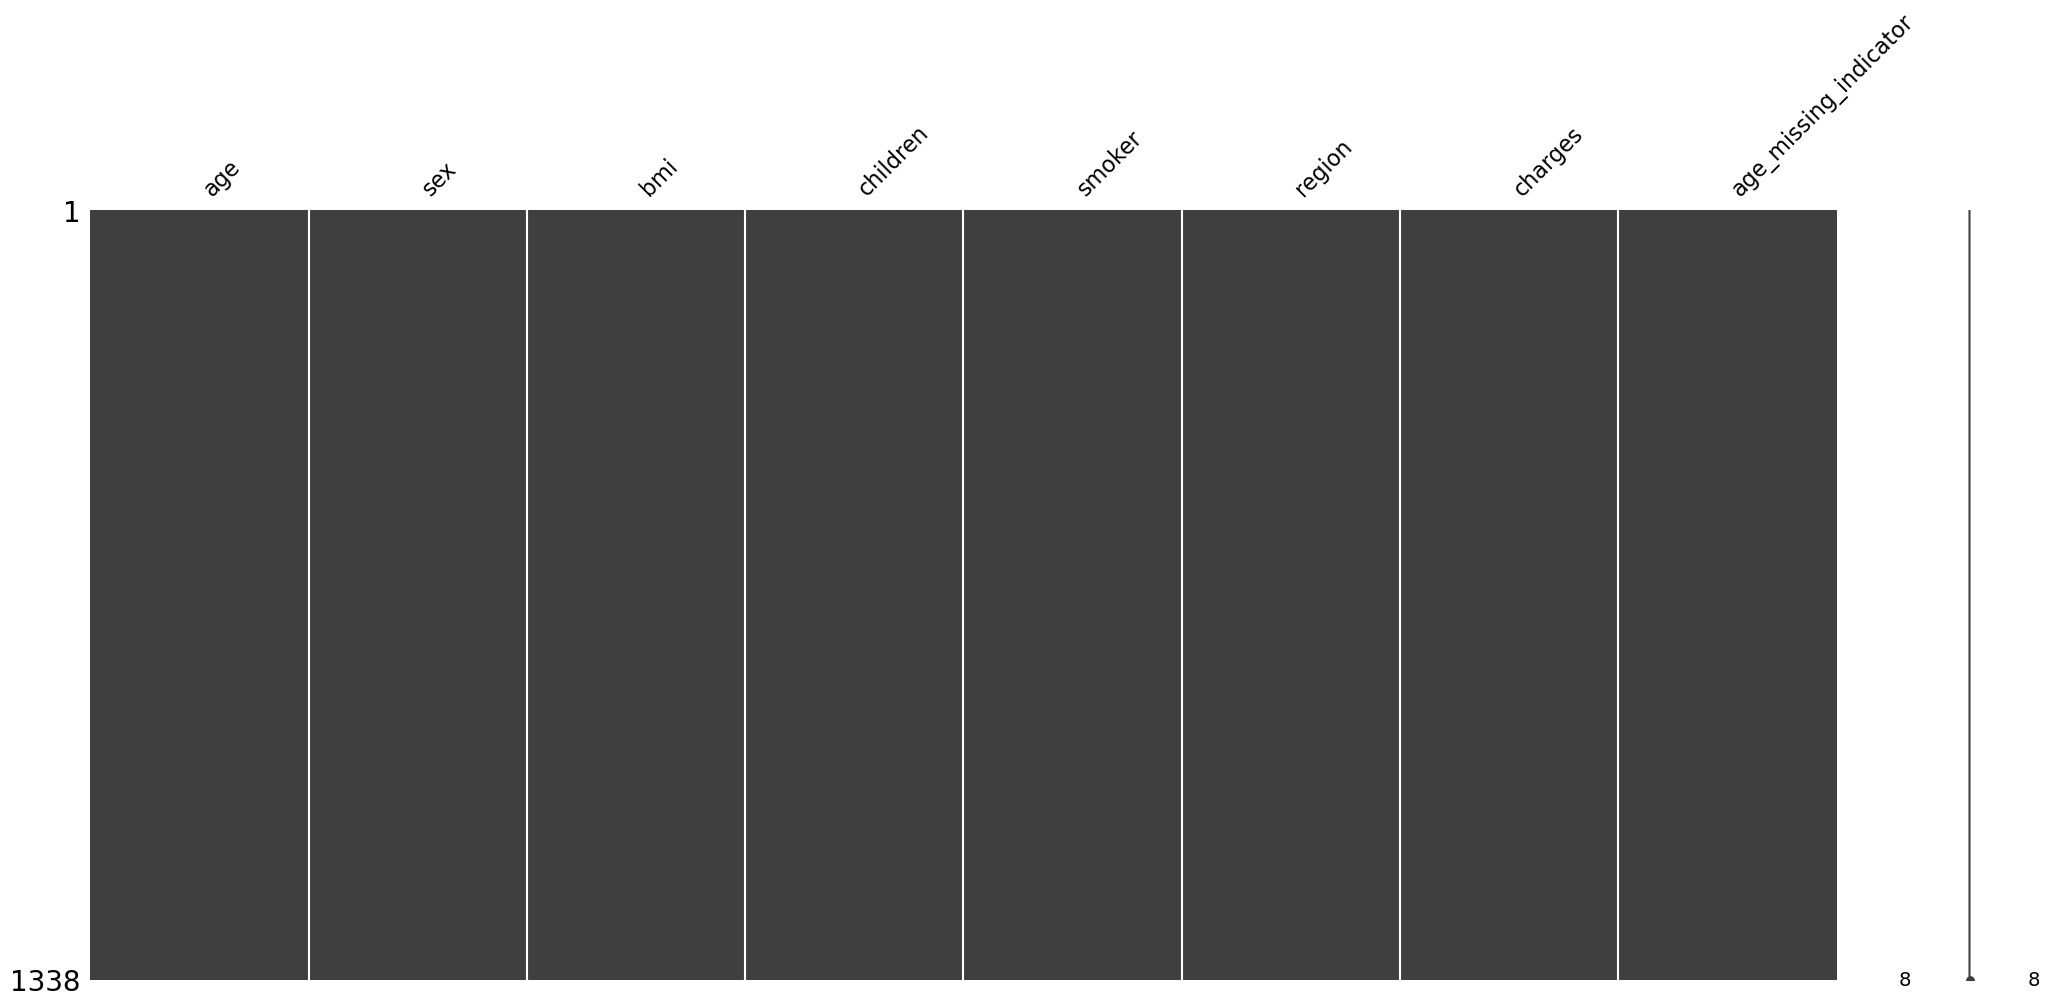

In [174]:
msno.matrix(df_clean)

### Answer for Question 3:

I used mode for MCAR chilren because the missing values are assumed to be unrelated to the other variable, so replacing them with the most common value is a simple way to keep the rows. For MAR BMI, I used median within smoker's groups because the missingnes depends on another observed feature which is smoker, so imputing within groups keeps that relationship better than using one overall median. For MNAR age, I use row deletion or rather a missing indicator because the fact that a value is missing may itself contain information

#  Encoding and Attribute Construction

Machine learning models usually need **numeric input**, but real-world datasets often contain **categorical data** (like colors, countries, or product types).  
To use this data in models, we apply **encoding techniques** that convert categories into numbers.  
We can also create **new features** from existing ones — this is called **attribute construction** (or feature engineering).  

---

### **Types of Encoding**

1. **Label Encoding**
- Converts categories into numbers (integers).  
- Best for **ordinal data** (where order matters, like Small < Medium < Large).  
-  Not good for nominal data because numbers may wrongly imply ranking.  

2. **One-Hot Encoding**
- Creates a separate binary column for each category.  
- Best for **nominal data** (where order does not matter, like Red, Blue, Green).  
-  Can increase dataset size if there are many categories.  

3. **Attribute Construction (Feature Engineering)**
- Creates new features (categorical or numerical) from existing ones.  
- Useful for adding more **meaningful information** to the dataset.  
- Example: From a date, we can extract **Day, Hour, Is_Weekend**.  

---

###  Summary Table

| **Method**              | **What it Does**                                  | **Example (Input)**          | **Example (Output)**                                             | **When to Use** |
|--------------------------|---------------------------------------------------|-------------------------------|------------------------------------------------------------------|-----------------|
| **Label Encoding**       | Assigns each category a number.                   | Size = {Small, Medium, Large} | Small=0, Medium=1, Large=2                                       | For **ordinal** data (ordered categories). |
| **One-Hot Encoding**     | Creates a binary column for each category.        | Color = {Red, Green, Blue}    | Red → [1,0,0], Green → [0,1,0], Blue → [0,0,1]                  | For **nominal** data (unordered categories). |
| **Attribute Construction** | Creates new categorical or numerical features from existing ones. | Date = `2023-09-13 14:35:00` | New Features → `Day = Wednesday`, `Hour = 14`, `Is_Weekend = No` | When we want to extract **useful patterns** from existing attributes. |

---

 In short:  
- **Label Encoding** = numbers for ordered categories.  
- **One-Hot Encoding** = binary columns for unordered categories.  
- **Attribute Construction** = build new features from existing ones.  


# **Question 4: Choosing the Right Encoding for Categorical Features**

In this exercise, you will decide which encoding method is most suitable for each categorical variable in the dataset, then apply it using scikit-learn.  

---

### **Your Task**

1. Inspect the dataset and identify the categorical features.  
   - Example: `sex`, `smoker`, `region`  

2. For each categorical feature:  
   - Suggest which type of encoding is **most appropriate** (Label Encoding, One-Hot Encoding, etc.).  
   - Explain why you chose that method.  

3. Apply the encoding using different classes from **`sklearn.preprocessing`**, such as:  
   - `LabelEncoder`  
   - `OneHotEncoder`  
   - `OrdinalEncoder`  

4. Compare your encoded dataset with the original:  
   - Which features are binary categorical?  
      - Smoker and sex are binary categorical
   - Which features are nominal categorical? 
      - region is nomial categorical 
   - Which features (if any) could be considered ordinal?  
      - None
   

5. In a **text cell**, write your explanation in 2–3 sentences for each feature:  
   - Why you chose that encoding method.  
   - Why another method might not be appropriate.  

   `sex` and `smoker` are binary categorical features, so I encoded it as 0 and 1. Since it only has 2 categories, using binary column is reasonable. One-hot encoding could also be used, but for a binary feature it would be less compact.
   `region` is a nominal categorical feature because the regions do not have a natural order. I used one-hot encoding so each region gets its own column, while lable or ordinal encoding could incorrectly suggest an order between regions.



### Scikit-learn

In [179]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
 
categorical_cols = df_clean.select_dtypes(include='object').columns
print(categorical_cols)

sex_encoder = LabelEncoder()
smoker_encoder = LabelEncoder()

df_encode = df_clean.copy()
df_encode['sex'] = sex_encoder.fit_transform(df_clean['sex'])
df_encode['smoker'] = smoker_encoder.fit_transform(df_clean['smoker'])

Index(['sex', 'smoker', 'region'], dtype='object')


In [180]:
sex_encoder.classes_, smoker_encoder.classes_

(array(['female', 'male'], dtype=object), array(['no', 'yes'], dtype=object))

In [181]:
region_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

region_encoded = region_encoder.fit_transform(df_encode[['region']])
region_encoder.categories_, region_encoded

([array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)],
 array([[0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        ...,
        [0., 0., 1., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.]]))

In [183]:
df_encode

,age,sex,bmi,children,smoker,region,charges,age_missing_indicator
0,19.0,0,27.900,0.0,1,southwest,16884.92400,0
1,40.0,1,33.770,1.0,0,southeast,1725.55230,1
2,28.0,1,33.000,3.0,0,southeast,4449.46200,0
3,33.0,1,22.705,0.0,0,northwest,21984.47061,0
4,32.0,1,28.880,0.0,0,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50.0,1,30.970,3.0,0,northwest,10600.54830,0
1334,18.0,0,31.920,0.0,0,northeast,2205.98080,0
1335,40.0,0,36.850,0.0,0,southeast,1629.83350,1
1336,21.0,0,25.800,0.0,0,southwest,2007.94500,0


In [184]:
df_region = pd.DataFrame(region_encoded, columns=region_encoder.get_feature_names_out(['region']), index=df_encode.index)
df_encode = df_encode.drop(columns=['region']).join(df_region)
df_encode


,age,sex,bmi,children,smoker,charges,age_missing_indicator,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,0,27.900,0.0,1,16884.92400,0,0.0,0.0,0.0,1.0
1,40.0,1,33.770,1.0,0,1725.55230,1,0.0,0.0,1.0,0.0
2,28.0,1,33.000,3.0,0,4449.46200,0,0.0,0.0,1.0,0.0
3,33.0,1,22.705,0.0,0,21984.47061,0,0.0,1.0,0.0,0.0
4,32.0,1,28.880,0.0,0,3866.85520,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50.0,1,30.970,3.0,0,10600.54830,0,0.0,1.0,0.0,0.0
1334,18.0,0,31.920,0.0,0,2205.98080,0,1.0,0.0,0.0,0.0
1335,40.0,0,36.850,0.0,0,1629.83350,1,0.0,0.0,1.0,0.0
1336,21.0,0,25.800,0.0,0,2007.94500,0,0.0,0.0,0.0,1.0


# 🔸 Normalization vs Standardization

When working with datasets, features (columns) often have different scales.  
For example:  
- **Age** might range from 18 to 80  
- **Income** might range from 10,000 to 200,000  

Some machine learning models (like KNN, SVM, Neural Networks) are sensitive to these differences in scale.  
To fix this, we use **feature scaling** methods like **Normalization** and **Standardization**.  

---

##  Normalization (Min-Max Scaling)

- Rescales values to a fixed range, usually **[0, 1]**.  
- Formula:  

\[
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
\]

- Example: If Age ranges from 18–80, then:  
  - 18 → 0.0  
  - 80 → 1.0  
  - 49 → ~0.5  

✔ Useful when features have very different ranges and we want everything between 0 and 1.  

---

##  Standardization (Z-Score Scaling)

- Rescales values so they have **mean = 0** and **standard deviation = 1**.  
- Formula:  

\[
x' = \frac{x - \mu}{\sigma}
\]

(where μ = mean, σ = standard deviation)  

- Example: If Age has mean = 40 and std = 10, then:  
  - Age 50 → (50-40)/10 = 1.0  
  - Age 30 → (30-40)/10 = -1.0  

✔ Useful for algorithms that assume data is normally distributed (e.g., Logistic Regression, SVM, PCA).  


# Question 5

1. Apply **Normalization** to your dataset using either a custom function or `MinMaxScaler` from `sklearn.preprocessing`.  
2. Apply **Standardization** to the same dataset using either a custom function or `StandardScaler`.  
3. Compare the results:  
   - Which features are now between 0 and 1?  
   - Which features now have mean ~0 and std ~1?  
4. In a **text cell**, explain in 2–3 sentences:  
   - When would you use **Normalization**?  
   - When would you use **Standardization**?  


In [195]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
numeric_cols = ['age', 'bmi', 'children']
X_features = df_encode.drop(columns=['charges'])
y_label = df_encode['charges']
X_features.head()

,age,sex,bmi,children,smoker,age_missing_indicator,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,0,27.900,0.0,1,0,0.0,0.0,0.0,1.0
1,40.0,1,33.770,1.0,0,1,0.0,0.0,1.0,0.0
2,28.0,1,33.000,3.0,0,0,0.0,0.0,1.0,0.0
3,33.0,1,22.705,0.0,0,0,0.0,1.0,0.0,0.0
4,32.0,1,28.880,0.0,0,0,0.0,1.0,0.0,0.0


In [196]:
X_normalized = X_features.copy()
X_normalized[numeric_cols] = minmax_scaler.fit_transform(X_features[numeric_cols])
X_normalized.head()

,age,sex,bmi,children,smoker,age_missing_indicator,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0,0.321227,0.0,1,0,0.0,0.0,0.0,1.0
1,0.478261,1,0.479150,0.2,0,1,0.0,0.0,1.0,0.0
2,0.217391,1,0.458434,0.6,0,0,0.0,0.0,1.0,0.0
3,0.326087,1,0.181464,0.0,0,0,0.0,1.0,0.0,0.0
4,0.304348,1,0.347592,0.0,0,0,0.0,1.0,0.0,0.0


In [197]:
X_standardized = X_features.copy()
X_standardized[numeric_cols] = standard_scaler.fit_transform(X_features[numeric_cols])
X_standardized.head()

,age,sex,bmi,children,smoker,age_missing_indicator,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.488136,0,-0.456302,-0.816127,1,0,0.0,0.0,0.0,1.0
1,0.033633,1,0.532568,0.026449,0,1,0.0,0.0,1.0,0.0
2,-0.835949,1,0.402853,1.711600,0,0,0.0,0.0,1.0,0.0
3,-0.473623,1,-1.331461,-0.816127,0,0,0.0,1.0,0.0,0.0
4,-0.546089,1,-0.291210,-0.816127,0,0,0.0,1.0,0.0,0.0


In [198]:
print("df_normalized")
X_normalized.describe()


df_normalized


,age,sex,bmi,children,smoker,age_missing_indicator,region_northeast,region_northwest,region_southeast,region_southwest
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,0.468171,0.505232,0.394098,0.193722,0.204783,0.014948,0.242152,0.242900,0.272048,0.242900
std,0.300106,0.500160,0.159760,0.237456,0.403694,0.121389,0.428546,0.428995,0.445181,0.428995
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.195652,0.000000,0.281141,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.478261,1.000000,0.380683,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.717391,1.000000,0.493947,0.400000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [199]:

print("df_standardized")
X_standardized.describe()

df_standardized


,age,sex,bmi,children,smoker,age_missing_indicator,region_northeast,region_northwest,region_southeast,region_southwest
count,1.338000e+03,1338.000000,1.338000e+03,1.338000e+03,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,-1.380726e-16,0.505232,-2.549032e-16,-5.177722e-17,0.204783,0.014948,0.242152,0.242900,0.272048,0.242900
std,1.000374e+00,0.500160,1.000374e+00,1.000374e+00,0.403694,0.121389,0.428546,0.428995,0.445181,0.428995
min,-1.560601e+00,0.000000,-2.467735e+00,-8.161274e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-9.084144e-01,0.000000,-7.073101e-01,-8.161274e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.363294e-02,1.000000,-8.400172e-02,2.644857e-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.307499e-01,1.000000,6.252222e-01,8.690245e-01,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.772797e+00,1.000000,3.793987e+00,3.396752e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Answer for Question 5:

3. Compare the results:  
   - Which features are now between 0 and 1? Normalized. age`, `bmi`, and `children` after normalization. The encoded categorical variables were already represented by 0 and 1.
   - Which features now have mean ~0 and std ~1?  Standardized
4. In a **text cell**, explain in 2–3 sentences:  
   - When would you use **Normalization**?  
   - When would you use **Standardization**?  

   I would use Normalization when I want all features to have the same fixed range, usually between 0 and 1. This can be useful when features have very different ranges and the algorithm is sensitive to distances between values 
   I would use Standardization when I want the features to be centered around 0 with a standard deviation of 1. It is useful when the scale of the features differs but I want to keep how far each value is from its mean.